# 📊 重回帰分析やってみよう

## このNotebookでやること
スライド21の数式
> 売上本数 = 5.2 × 気温 + (-0.8) × 湿度 + 30 × イベント + (-12)

を、印刷機データで体験します。

**ターゲット**: 機体ごとの 月平均印刷枚数（mean_prints）
**入力**: 機種・コントローラ・オプション搭載数・休止月数 など

## ランダムフォレストとの違い
| 観点 | ランダムフォレスト | 重回帰分析 |
|---|---|---|
| 仕組み | 500本の決定木の平均 | **数式 1 本** で予測 |
| 解釈 | 重要度ランキング | **係数で「+/-どっち向きにどれだけ効く」** |
| 形 | 複雑な関係も拾える | 直線的な関係のみ |

迷ったら手を挙げて講師を呼んでください 🙋


---
## 1. 環境セットアップ


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
try:
    import japanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = ["Yu Gothic", "Meiryo", "MS Gothic", "sans-serif"]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

DATA_DIR    = Path(r"C:\Users\nakai\Desktop\Claude\FY26_ds\pp_ rawdata_2nd")
META_DIR    = DATA_DIR / "meta"
OPTION_DIR  = DATA_DIR / "option"
MASTER_DIR  = DATA_DIR / "master"

print("META_DIR exists:", META_DIR.exists())


META_DIR exists: True


---
## 2. 月次データを 17ヶ月分まとめて読み込み


In [2]:
def extract_yyyymm(filename: str):
    m = re.search(r"_(\d{6})\.csv$", filename)
    return m.group(1) if m else None

META_COLS = ["mach_id","model_cd","pmtc_counter","create_update_date"]
frames = []
for f in sorted(META_DIR.glob("metadata_*.csv")):
    ym = extract_yyyymm(f.name)
    if ym:
        df = pd.read_csv(f, low_memory=False, usecols=lambda c: c in META_COLS)
        df["yyyymm"] = ym
        frames.append(df)

meta_long = pd.concat(frames, ignore_index=True)
meta_long["yyyymm"] = pd.to_datetime(meta_long["yyyymm"] + "01", format="%Y%m%d")
meta_long["pmtc_counter"] = pd.to_numeric(meta_long["pmtc_counter"], errors="coerce")

print("月次データ shape:", meta_long.shape)
print("ユニーク機体数:", meta_long["mach_id"].nunique())


月次データ shape: (364250, 5)
ユニーク機体数: 30293


---
## 3. 月間印刷枚数を計算


In [3]:
meta_long = meta_long.sort_values(["mach_id","yyyymm"]).reset_index(drop=True)
meta_long["prev_counter"] = meta_long.groupby("mach_id")["pmtc_counter"].shift(1)
meta_long["monthly_prints"] = meta_long["pmtc_counter"] - meta_long["prev_counter"]
meta_long.loc[meta_long["monthly_prints"] < 0, "monthly_prints"] = np.nan
upper = meta_long["monthly_prints"].quantile(0.995)
meta_long.loc[meta_long["monthly_prints"] > upper, "monthly_prints"] = np.nan

print(meta_long["monthly_prints"].describe().round(0))


count     318061.0
mean       79200.0
std       135294.0
min            0.0
25%         8035.0
50%        28039.0
75%        87305.0
max      1132359.0
Name: monthly_prints, dtype: float64


---
## 4. 機体ごとに集計してターゲットと特徴量を作る


In [4]:
agg = meta_long.groupby("mach_id").agg(
    model_cd=("model_cd","first"),
    mean_prints=("monthly_prints","mean"),
    n_active_months=("monthly_prints", lambda s: s.notna().sum()),
    idle_months=("monthly_prints", lambda s: (s == 0).sum()),
).reset_index()
print("機体テーブル:", agg.shape)
agg.head()


機体テーブル: (30293, 5)


,mach_id,model_cd,mean_prints,n_active_months,idle_months
0,A50U001000242,C1070,NaN,0,0
1,A50U001000312,C1070,NaN,0,0
2,A50U001000422,C1070,NaN,0,0
3,A50U001000606,C1070,NaN,0,0
4,A50U001000608,C1070,NaN,0,0


---
## 5. オプション情報を結合


In [5]:
opt_files = sorted(OPTION_DIR.glob("option_*.csv"))
latest_opt = opt_files[-1]
opt = pd.read_csv(latest_opt, low_memory=False)

opt_cols = [c for c in opt.columns if c.startswith("option_item")]
opt_flag = opt[["mach_id"] + opt_cols].copy()
for c in opt_cols:
    opt_flag[c] = (opt_flag[c].notna() & (opt_flag[c].astype(str) != "None") & (opt_flag[c].astype(str) != "")).astype(int)
opt_flag["option_count"] = opt_flag[opt_cols].sum(axis=1)

agg = agg.merge(opt_flag[["mach_id","option_count"]], on="mach_id", how="left")
agg["option_count"] = agg["option_count"].fillna(0).astype(int)
print("オプション搭載数:")
print(agg["option_count"].describe().round(1))


オプション搭載数:
count    30293.0
mean         4.1
std          3.1
min          0.0
25%          2.0
50%          4.0
75%          6.0
max         19.0
Name: option_count, dtype: float64


---
## 6. 機種マスタを結合


In [6]:
m_product = pd.read_csv(MASTER_DIR / "product.csv", encoding="utf-8-sig")
agg["mach_prefix"] = agg["mach_id"].str[:4]
agg = agg.merge(
    m_product[["product","product_name","controller"]].rename(columns={"product":"mach_prefix"}),
    on="mach_prefix", how="left"
)
agg.head()


,mach_id,model_cd,mean_prints,n_active_months,idle_months,option_count,mach_prefix,product_name,controller
0,A50U001000242,C1070,NaN,0,0,0,A50U,NaN,NaN
1,A50U001000312,C1070,NaN,0,0,4,A50U,NaN,NaN
2,A50U001000422,C1070,NaN,0,0,0,A50U,NaN,NaN
3,A50U001000606,C1070,NaN,0,0,0,A50U,NaN,NaN
4,A50U001000608,C1070,NaN,0,0,2,A50U,NaN,NaN


---
## 7. 学習用データを準備


In [7]:
ml = agg[agg["mean_prints"].notna() & (agg["n_active_months"] >= 3)].copy()
print(f"学習対象機体: {len(ml):,}台")

y = ml["mean_prints"]
X = ml[["option_count","idle_months","n_active_months","model_cd","product_name","controller"]]
X = pd.get_dummies(X, columns=["model_cd","product_name","controller"], dummy_na=True)
X = X.astype({c: int for c in X.select_dtypes(include="bool").columns})
print(f"特徴量の数: {X.shape[1]}")


学習対象機体: 24,939台
特徴量の数: 68


---
## 8. 訓練データ / テストデータに分ける


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"訓練: {len(X_train):,}台 / テスト: {len(X_test):,}台")


訓練: 19,951台 / テスト: 4,988台


---
## 9. 📊 重回帰分析（線形回帰）を学習

スライド21の数式の形:
> 売上 = 係数₁ × 気温 + 係数₂ × 湿度 + 係数₃ × イベント + 切片

を、たくさんの特徴量に拡張して学習します。


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr  = r2_score(y_test, pred_lr)
print(f"📊 重回帰分析:")
print(f"  MAE = {mae_lr:,.0f} 枚/月")
print(f"  R²  = {r2_lr:.3f}")
print(f"  切片 (intercept) = {lr.intercept_:,.1f}")


📊 重回帰分析:
  MAE = 53,483 枚/月
  R²  = 0.387
  切片 (intercept) = 149,134.7


---
## 10. 🔍 係数（数式）を見てみる

スライド21の
> +5.2  気温1℃UP → 売上が5.2本増える

の「+5.2」にあたるのが **係数**。
今回の場合は「その特徴量が 1 増えると、月平均印刷枚数が何枚 変化するか」を意味します。


In [10]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef":    lr.coef_,
}).sort_values("coef", key=abs, ascending=False)

print("=== 係数の絶対値 TOP15 ===")
print(coef_df.head(15).to_string(index=False))


=== 係数の絶対値 TOP15 ===
                      feature          coef
          model_cd_PRESS6272P 200819.111344
           model_cd_PRESS6136 153092.240153
product_name_PittIslandMLK1_4 151584.071450
            model_cd_LABEL230 -85046.782557
              model_cd_C14000  82501.986349
             model_cd_C14010S  82156.099542
               model_cd_C5065 -76700.951252
product_name_PittIslandMLK1_5 -74849.875532
           model_cd_PRESS6120  74790.542806
    product_name_SymphonyMe1P  74006.617092
               model_cd_C2060 -72238.412284
               model_cd_C3070 -67962.382341
            controller_IC-610  65305.441814
               controller_AIO  63348.365603
            controller_IC-607 -62710.444098


In [11]:
# 数式の意味を読む（数値特徴量だけ）
numeric_features = ["option_count","idle_months","n_active_months"]
for feat in numeric_features:
    if feat in coef_df["feature"].values:
        c = coef_df.loc[coef_df["feature"]==feat, "coef"].iloc[0]
        sign = "増える" if c > 0 else "減る"
        print(f"  {feat} が 1 増えると、月平均印刷枚数が {abs(c):,.0f} 枚 {sign}")


  option_count が 1 増えると、月平均印刷枚数が 1,581 枚 減る
  idle_months が 1 増えると、月平均印刷枚数が 12,441 枚 減る
  n_active_months が 1 増えると、月平均印刷枚数が 859 枚 減る


---
## 11. 係数の可視化（どっち向きに効いているか）

正の係数 = 印刷枚数を **増やす方向** に効く
負の係数 = 印刷枚数を **減らす方向** に効く


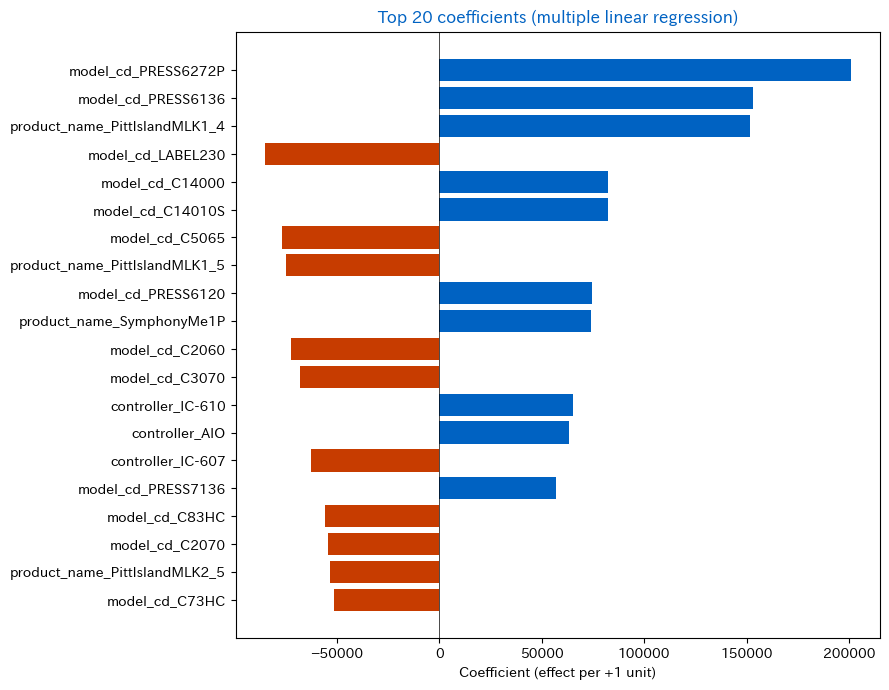

In [12]:
top_coef = coef_df.head(20).iloc[::-1]   # 表示用に逆順
colors = ["#0062C2" if v > 0 else "#C73C00" for v in top_coef["coef"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_coef["feature"], top_coef["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient (effect per +1 unit)")
ax.set_title("Top 20 coefficients (multiple linear regression)", color="#0062C2", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 12. 予測 vs 実測の散布図


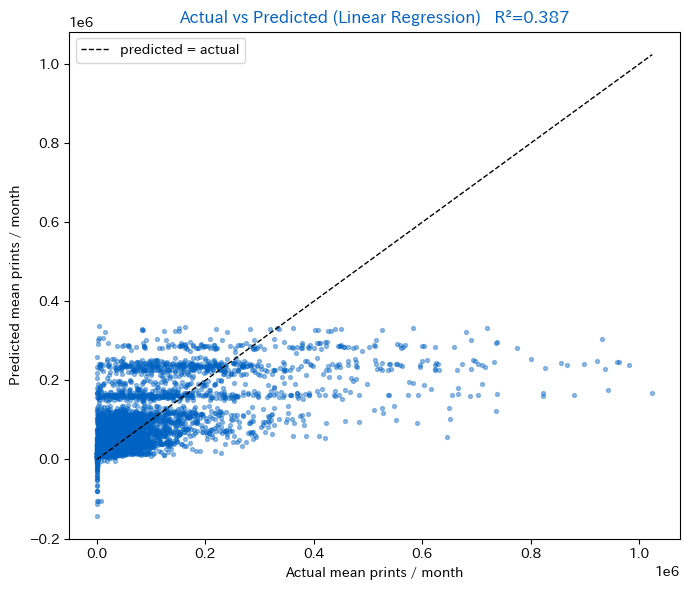

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, pred_lr, s=8, alpha=0.4, color="#0062C2")
lim = max(y_test.max(), pred_lr.max())
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="predicted = actual")
ax.set_xlabel("Actual mean prints / month")
ax.set_ylabel("Predicted mean prints / month")
ax.set_title(f"Actual vs Predicted (Linear Regression)   R²={r2_lr:.3f}", color="#0062C2", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


---
## 13. 🌳 ランダムフォレストとの比較

同じデータでランダムフォレストも回して、結果を並べて見ます。
（スライド22「直線的な関係しか表せない」「複雑な関係もある」の体感）


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf  = r2_score(y_test, pred_rf)

print("=== 重回帰 vs ランダムフォレスト ===")
print(f"  重回帰          : MAE = {mae_lr:,.0f}, R² = {r2_lr:.3f}")
print(f"  ランダムフォレスト: MAE = {mae_rf:,.0f}, R² = {r2_rf:.3f}")


=== 重回帰 vs ランダムフォレスト ===
  重回帰          : MAE = 53,483, R² = 0.387
  ランダムフォレスト: MAE = 55,355, R² = 0.328


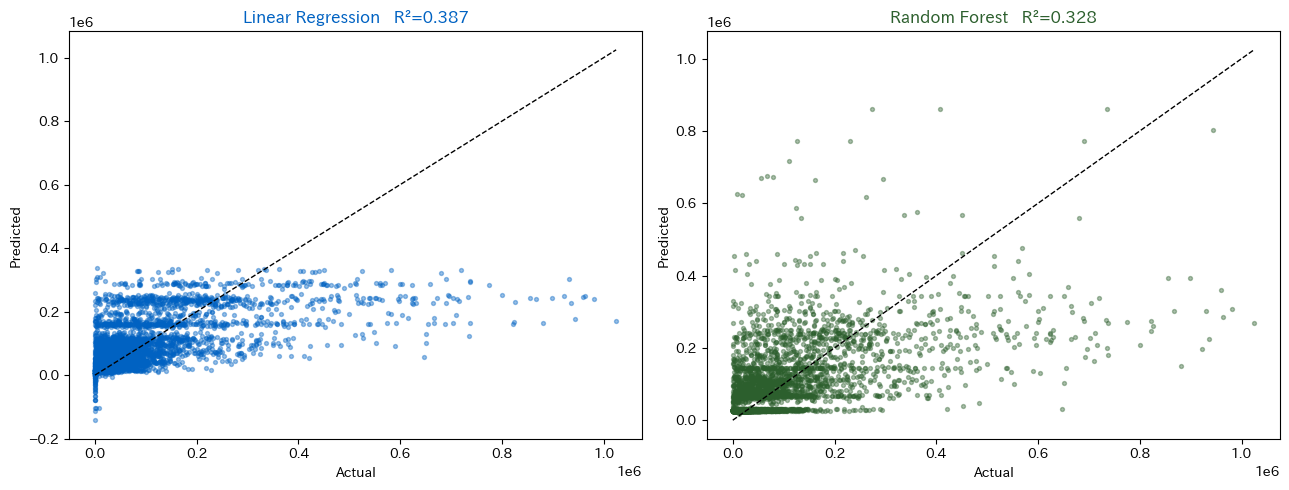

In [15]:
# 散布図で並べて見る
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, pred_lr, s=8, alpha=0.4, color="#0062C2")
lim = max(y_test.max(), pred_lr.max())
axes[0].plot([0, lim], [0, lim], "k--", linewidth=1)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Linear Regression   R²={r2_lr:.3f}", color="#0062C2", fontweight="bold")

axes[1].scatter(y_test, pred_rf, s=8, alpha=0.4, color="#2C5F2D")
lim = max(y_test.max(), pred_rf.max())
axes[1].plot([0, lim], [0, lim], "k--", linewidth=1)
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Random Forest   R²={r2_rf:.3f}", color="#2C5F2D", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 14. 振り返り

このNotebookでやったこと:

| ステップ | スライド | コード |
|---|---|---|
| 数式 1 本で予測 | スライド21 | `LinearRegression` |
| 係数を読む = どっち向きに効くか | スライド21 | `lr.coef_` |
| 重回帰 vs RF の精度比較 | スライド22 | 散布図2枚並列 |

### 大事なメッセージ
- 重回帰は **「+の係数=増やす」「-の係数=減らす」が一目で分かる**（解釈性）
- ただし **直線的な関係しか拾えない**ので、複雑な関係はRFに負けがち
- 「**どちらが優れているか** ではなく **目的に応じて使い分け**」（スライド28-30）
  - 解釈・説明したい → 重回帰
  - 精度が欲しい → ランダムフォレスト
